In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import cftime
from scipy.interpolate import griddata
import xesmf as xe

# for year in {1940..2020}; do cdo monmean $year/ice.$year.nc $year/ice_monthly.$year.nc; done
# for year in {1958..2020}; do cdo -gtc,0 $year/ice_monthly.$year.nc $year/ice_mask.$year.nc; done

YEAR_START = 1959
YEAR_FIN = 2019

out_var_type = 'ocn'

PATH = "/glade/campaign/cgd/oce/people/rita/CESM_OUTPUT/a.e30.A_JRA55raw.TL319_t232.daily_SST_ERA5/MONTHLY/"


PATH_landmask = '/glade/derecho/scratch/mmarkina/archive/a.e30.A_JRA55raw.TL319_t232.time_varying_HadOIBl/cpl/hist/'
filename_raw = 'a.e30.A_JRA55raw.TL319_t232.time_varying_HadOIBl.cpl.hi.1959-12-31-81000.nc'

if out_var_type == 'ocn':
    output_lat = xr.open_dataset(PATH_landmask + filename_raw, engine="netcdf4")['ocnExp_lat'].isel(time=0).drop_vars('time').rename({"ocnExp_ny": "y", "ocnExp_nx": "x"})
    output_lon = xr.open_dataset(PATH_landmask + filename_raw, engine="netcdf4")['ocnExp_lon'].isel(time=0).drop_vars('time').rename({"ocnExp_ny": "y", "ocnExp_nx": "x"})
elif out_var_type == 'atm':
    output_lat = xr.open_dataset(PATH_landmask + filename_raw, engine="netcdf4")['atmImp_lat'].isel(time=0).drop_vars('time').rename({"atmImp_ny": "y", "atmImp_nx": "x"})
    output_lon = xr.open_dataset(PATH_landmask + filename_raw, engine="netcdf4")['atmImp_lon'].isel(time=0).drop_vars('time').rename({"atmImp_ny": "y", "atmImp_nx": "x"})

    
# PATH_icemask = "/glade/campaign/cgd/oce/people/rita/HadOIBl_SSTICE/"

PATH_icemask = "/glade/campaign/cgd/oce/people/rita/ERA5/"

if out_var_type == 'ocn':
    variables = {
        "latent": "ocnExp_Foxx_lat",
        "sensible": "ocnExp_Foxx_sen",
        "swnet": "ocnExp_Foxx_swnet",
        "lwnet": "ocnExp_Foxx_lwnet"
    }
elif out_var_type == 'atm':
    variables = {
        "atm_swnet": "atmImp_Faxa_swnet"
    }

icemask_filename = 'ERA5_ice_monthly_1940_2020.nc'

mask_ds =  xr.open_dataset(PATH_icemask + icemask_filename)

# Convert cftime to pandas Timestamp
# mask_ds = mask_ds.assign_coords(time=[pd.Timestamp(t.strftime("%Y-%m-%d %H:%M:%S")) for t in mask_ds.time.values])

In [2]:
%%time
ice_fraction_multi = 1 - mask_ds.ice_cov

CPU times: user 3.17 s, sys: 9.79 s, total: 13 s
Wall time: 52.2 s


In [3]:
def convert_ocnExp_to_atmImp_mask(PATH, filename):
    '''
    PATH - path to raw model output files 
    filename - filename of one of these files (to read coords of ocnExp and atmImp)
    '''
    lat_in = xr.open_dataset(PATH + filename)['ocnExp_lat'].isel(time=0, drop = True)
    lon_in = xr.open_dataset(PATH + filename)['ocnExp_lon'].isel(time=0, drop = True) % 360

    mask = xr.open_dataset(PATH + filename, engine="netcdf4")['ocnImp_So_omask'].isel(time=0, drop = True).rename({"ocnImp_ny": "ocnExp_ny", "ocnImp_nx": "ocnExp_nx"})
    
    mask_in = xr.DataArray(mask.values, dims=("y", "x"),
                           coords={"lon": (("y", "x"), lon_in.values), "lat": (("y", "x"), lat_in.values)},
                           name="mask")
    
    
    lat_out = xr.open_dataset(PATH + filename)['atmImp_lat'].isel(time=0, drop = True)
    lon_out = xr.open_dataset(PATH + filename)['atmImp_lon'].isel(time=0, drop = True)
    
    # Create xESMF regridder for curvilinear grid
    grid_in = xr.Dataset({"lat": (("y", "x"), lat_in.values), "lon": (("y", "x"), lon_in.values)})
    grid_out = xr.Dataset({"lat": (("y", "x"), lat_out.values), "lon": (("y", "x"), lon_out.values)})
    
    regridder = xe.Regridder(grid_in, grid_out, "nearest_s2d")  # 'nearest_s2d' is best for masks
    
    # Apply regridding
    mask_out = regridder(mask_in)
    mask_out = mask_out.rename("mask")  # Explicitly set the name

    mask_out_da = xr.DataArray(mask_out.values, dims=("y", "x"),
                       coords={"longitude": (("y", "x"), lon_out.values), "latitude": (("y", "x"), lat_out.values)},
                       name="mask")


    return mask_out_da

In [4]:
if out_var_type == 'ocn':
    land_mask = xr.open_dataset(PATH_landmask + filename_raw, engine="netcdf4")['ocnImp_So_omask'].isel(time=0).drop_vars('time').rename({"ocnImp_ny": "y", "ocnImp_nx": "x"})
    land_mask = land_mask.where(land_mask != 0, np.nan)

elif out_var_type == 'atm':
    land_mask = convert_ocnExp_to_atmImp_mask(PATH_landmask, filename_raw)
    land_mask = land_mask.where(land_mask != 0, np.nan)

In [5]:
# Shift longitudes to be within [-180, 180]
output_lon = (output_lon + 360) % 360  # First, ensure longitudes are in [0, 360]
output_lon = ((output_lon + 180) % 360) - 180  # Convert to [-180, 180]

In [6]:
# Convert longitudes from [0, 360] to [-180, 180]
ice_fraction_multi["longitude"] = ((ice_fraction_multi["longitude"] + 180) % 360) - 180

In [7]:
for YEAR in range(YEAR_START, YEAR_FIN+1):  
    print(YEAR)
    
    for var_type, var_name in variables.items():
        # Load model data
        model_file = f"{PATH}{YEAR}.{var_type}.monthly.nc"
        model_ds = xr.open_dataset(model_file)

        if out_var_type == 'ocn':
            model_var = model_ds[var_name].rename({"ocnExp_ny": "y", "ocnExp_nx": "x"})
        elif out_var_type == 'atm':
            model_var = model_ds[var_name].rename({"atmImp_ny": "y", "atmImp_nx": "x"})

        ice_fraction_mask = ice_fraction_multi.sel(time=ice_fraction_multi.time.dt.year == YEAR)

        # # Convert ice mask to binary (NaN where ice > 0, 1 elsewhere)
        # ice_mask = xr.where(mask_var > 0, np.nan, 1)

        # Ensure time alignment
        ice_fraction_mask["time"] = model_var["time"]

        ice_mask_interp = ice_fraction_mask.interp(latitude=output_lat, longitude=output_lon, method="linear")#.rename({"lat": "y", "lon": "x"})

        # print(model_var)
        # print(ice_mask_interp)
        # print(land_mask)
        
        # Apply ice mask and land mask
        masked_model = model_var * ice_mask_interp * land_mask

        # Convert to dataset with proper variable name
        masked_model = masked_model.to_dataset(name=var_name)
        # masked_model['latitude'] = ice_mask_interp['latitude']
        # masked_model = masked_model.assign_coords(longitude=((ice_mask_interp.longitude + 360) % 360))

        # print(jjj)

        # Save masked data
        output_file = f"{PATH}{YEAR}.{var_type}.monthly_ice_mask.nc"
        masked_model.to_netcdf(output_file)

        print(f"Processed: {output_file}")

1959
Processed: /glade/campaign/cgd/oce/people/rita/CESM_OUTPUT/a.e30.A_JRA55raw.TL319_t232.daily_SST_ERA5/MONTHLY/1959.latent.monthly_ice_mask.nc
Processed: /glade/campaign/cgd/oce/people/rita/CESM_OUTPUT/a.e30.A_JRA55raw.TL319_t232.daily_SST_ERA5/MONTHLY/1959.sensible.monthly_ice_mask.nc
Processed: /glade/campaign/cgd/oce/people/rita/CESM_OUTPUT/a.e30.A_JRA55raw.TL319_t232.daily_SST_ERA5/MONTHLY/1959.swnet.monthly_ice_mask.nc
Processed: /glade/campaign/cgd/oce/people/rita/CESM_OUTPUT/a.e30.A_JRA55raw.TL319_t232.daily_SST_ERA5/MONTHLY/1959.lwnet.monthly_ice_mask.nc
1960
Processed: /glade/campaign/cgd/oce/people/rita/CESM_OUTPUT/a.e30.A_JRA55raw.TL319_t232.daily_SST_ERA5/MONTHLY/1960.latent.monthly_ice_mask.nc
Processed: /glade/campaign/cgd/oce/people/rita/CESM_OUTPUT/a.e30.A_JRA55raw.TL319_t232.daily_SST_ERA5/MONTHLY/1960.sensible.monthly_ice_mask.nc
Processed: /glade/campaign/cgd/oce/people/rita/CESM_OUTPUT/a.e30.A_JRA55raw.TL319_t232.daily_SST_ERA5/MONTHLY/1960.swnet.monthly_ice_mas

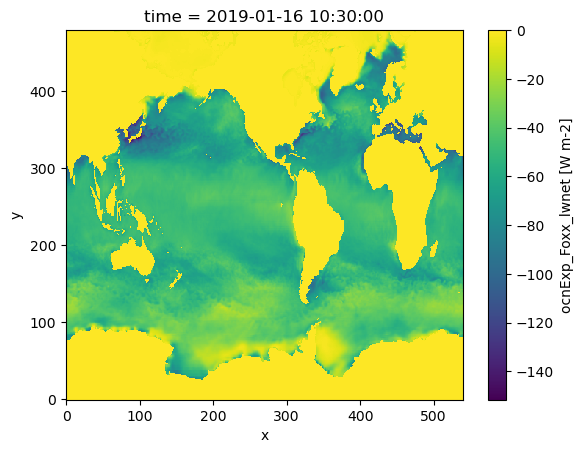

In [8]:
model_var.isel(time=0).plot()

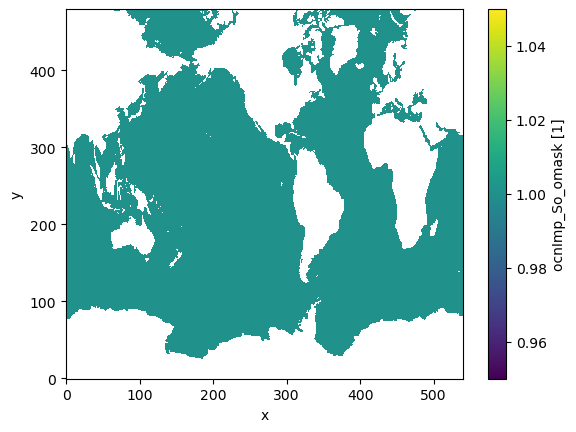

In [9]:
land_mask.plot()

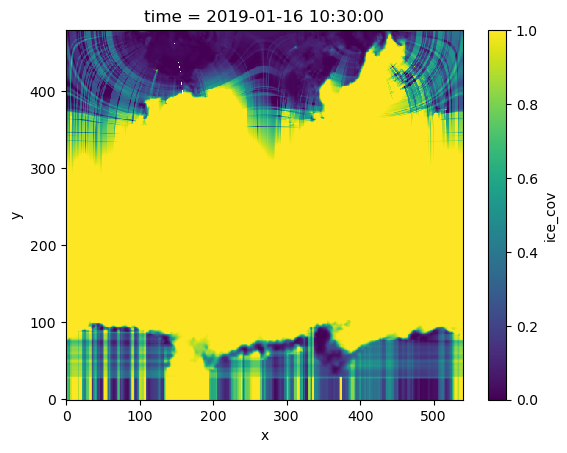

In [10]:
ice_mask_interp.isel(time=0).plot()

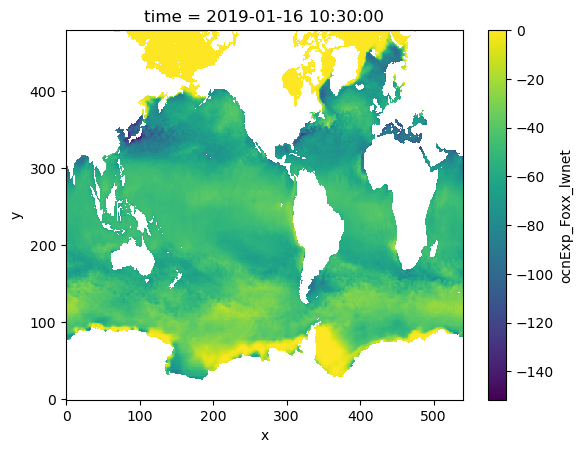

In [11]:
if out_var_type == 'atm':
    masked_model.atmImp_Faxa_swnet.isel(time=0).plot()
else:
    masked_model.ocnExp_Foxx_lwnet.isel(time=0).plot()

In [28]:
masked_model

<xarray.Dataset> Size: 29MB
Dimensions:            (time: 12, y: 480, x: 540)
Coordinates:
  * time               (time) object 96B 2019-01-16 10:30:00 ... 2019-12-16 1...
    latitude           (y, x) float64 2MB -81.56 -81.56 -81.56 ... 50.11 49.99
    longitude          (y, x) float64 2MB 73.33 74.0 74.67 ... 72.97 72.98 73.0
Dimensions without coordinates: y, x
Data variables:
    ocnExp_Foxx_lwnet  (time, y, x) float64 25MB nan nan nan nan ... nan nan nan